# Python Lesson 08: Systems of Linear Equations

**Concept page:** `wiki/concepts/systems-of-linear-equations.md` · **Area:** linear-algebra

**You will be able to:**
- write a system as A x = b
- solve it with NumPy and by substitution/elimination
- classify unique / none / infinite cases

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Fruit prices as a system
$a+b=10,\ a+2b=12$.

In [2]:
A=np.array([[1,1],[1,2]],float); b=np.array([10,12],float)
print(np.linalg.solve(A,b))   # apple 8, banana 2

[8. 2.]


## 2. Substitution (Grade 9) written as code

In [3]:
# y = 7 - 3x  and  2x - 3y = 12
x=sp.symbols('x'); y=7-3*x
xs=sp.solve(sp.Eq(2*x-3*y,12),x)[0]; print("x =",xs,"y =",y.subs(x,xs))

x = 3 y = -2


## 3. Three cases

In [4]:
def classify(A,b):
    A=np.array(A,float); b=np.array(b,float)
    rA=np.linalg.matrix_rank(A); rAb=np.linalg.matrix_rank(np.c_[A,b])
    if rA<rAb: return "no solution (contradictory)"
    if rA==A.shape[1]: return "unique solution"
    return "infinitely many solutions (redundant)"
print(classify([[1,1],[1,2]],[10,12]))
print(classify([[1,1],[2,2]],[10,20]))
print(classify([[1,1],[2,2]],[10,24]))

unique solution
infinitely many solutions (redundant)
no solution (contradictory)


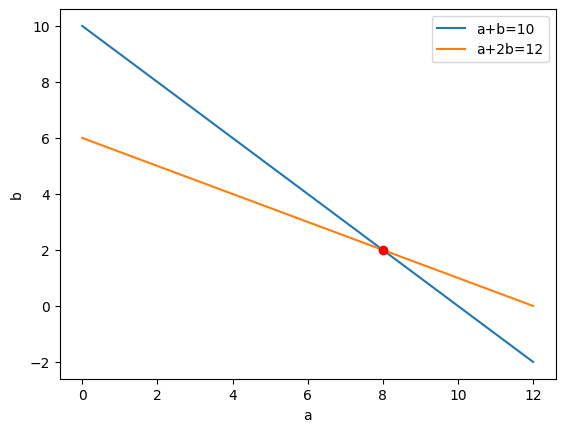

In [5]:
x=np.linspace(0,12,50)
plt.plot(x,10-x,label="a+b=10"); plt.plot(x,(12-x)/2,label="a+2b=12")
plt.scatter([8],[2],c='r',zorder=3); plt.legend(); plt.xlabel('a'); plt.ylabel('b'); plt.show()

## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 9 lesson 11: solve y = 7 − 3x, 2x − 3y = 12 → (3, −2); parallel lines x+3y=6 and x+3y=−3 have no solution; y=4−x and x/2+y/2=2 coincide.

In [6]:
print(classify([[1,3],[1,3]],[6,-3]), '|', classify([[1,1],[0.5,0.5]],[4,2]))

no solution (contradictory) | infinitely many solutions (redundant)


## Exercises

**Exercise 1.** Solve x+3y=6, 4x+3y=4... then x+3y=6 with x+3y=-3 and classify both.

In [7]:
# your code here

**Exercise 2.** Solve the 3x3 system a+b+c=10, a+2b+c=15, a+b+2c=12 (answer a=3,b=5,c=2).

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
print(classify([[1,3],[4,3]],[6,4]), classify([[1,3],[1,3]],[6,-3]))
assert classify([[1,3],[1,3]],[6,-3]).startswith('no')

unique solution no solution (contradictory)


In [10]:
# Solution 2
s=np.linalg.solve([[1,1,1],[1,2,1],[1,1,2]],[10,15,12]); print(s); assert np.allclose(s,[3,5,2])

[3. 5. 2.]
